# **SPIDER ML TASK - 1 : BASE TASK**
---

In [ ]:
import torch
import torch.nn as nn
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from openpyxl import Workbook
from openpyxl.drawing.image import Image
from torchvision.utils import save_image

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [ ]:
#hyperparameters
batch_size = 64

# Splitting Train, Val, Test Dataloaders
- Train DataLoader : Used for training the model. The model learns patterns from this dataset and update its weights and biases
- Validation Data : Used to validate the model during training, also it is here used for saving the best model
- Test DataLoader : Used only after training is complete to evaluate the final model performance. The test dataset must remain completely unseen during training and validation

In [ ]:
# normalizing the dataset
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_data = FashionMNIST(root='data',train=True ,download=True, transform=train_transform)
test_data = FashionMNIST(root='data',train=False ,download=True, transform=test_transform)

def train_val_split(train_data, val_size):
  train_data_size = len(train_data)
  val_index = int(train_data_size*(val_size))
  indices = np.random.permutation(train_data_size)
  val_data, train_data = indices[:val_index], indices[val_index:]
  return train_data, val_data

train_idx, val_idx, = train_val_split(train_data, 0.1)

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

train_dl = DataLoader(train_data, batch_size, sampler=train_sampler)
val_dl = DataLoader(train_data, batch_size, sampler=val_sampler)
test_dl = DataLoader(test_data, batch_size)

100%|██████████| 26.4M/26.4M [00:00<00:00, 111MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.06MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.6MB/s]


## Model architecture

In [ ]:
class FashionMNISTModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()

    self.hidden_lay_1 = nn.Sequential(nn.Linear(784, 16), nn.ReLU())

    self.hidden_left_1 = nn.Sequential(nn.Linear(16, 8),nn.ReLU())

    self.hidden_left_2 = nn.Sequential(nn.Linear(8, 8), nn.ReLU())

    self.hidden_right = nn.Sequential(nn.Linear(16, 12), nn.ReLU(), nn.Linear(12, 8), nn.ReLU())

    self.output = nn.Linear(16, 10)

  # forward propagation
  def forward(self, X):
    X = self.flatten(X)
    X = self.hidden_lay_1(X)

    X1 = self.hidden_left_1(X)
    fX1 = self.hidden_left_2(X1)

    X1 = fX1 + X1

    X2 = self.hidden_right(X)

    X_output = self.output(torch.cat((X1, X2), dim=1))

    return X_output

  def predict(self, X):
    labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    X = X.to(device)
    X = self.forward(X)
    return labels[torch.argmax(X, dim=1)]

In [ ]:
def accuracy(y_cap, y):
  return torch.sum(torch.argmax(y_cap, dim=1) == y).item() / len(y)

In [ ]:
def save_params(model, f):
  # saves the model
  with open(f, 'wb') as f:
    pickle.dump(model.state_dict(), f)

In [ ]:
def load_params(model, f):
  # loads the model
  with open(f, 'rb') as f:
    model.load_state_dict(pickle.load(f))

In [ ]:
def dl_accuracy(model, dl, loss_fn):
  # returns the accuracy and loss computed by the given model on a dataloader
  crt_pred=0
  total=0
  run_loss=0
  model.eval()
  with torch.no_grad():
    for X, y in dl:
      X = X.to(device)
      y = y.to(device)
      y_cap = model(X)
      loss = loss_fn(y_cap, y)
      run_loss += loss.item()
      crt_pred += torch.sum(torch.argmax(y_cap, dim=1) == y).item()
      total += len(y)

  return (crt_pred / total), run_loss / len(dl)

In [ ]:
def fit(dataset, model, opt, loss_fn, epochs=100):
  # fits the model on train data loader
  val_accs=[]
  val_losses=[]
  best_val_loss = float('inf')
  model.train()
  for epoch in range(1, epochs+1):
    total=0
    crt_pred=0
    for X, y in dataset:
      X = X.to(device)
      y = y.to(device)
      y_cap = model.forward(X)
      loss = loss_fn(y_cap, y)
      loss.backward()
      opt.step()
      opt.zero_grad()
      crt_pred += torch.sum(torch.argmax(y_cap, dim=1) == y).item()
      total += len(y)
    print("Epoch", epoch, "Train Accuracy : ", crt_pred/total)
    val_acc, val_loss = dl_accuracy(model, val_dl, loss_fn)
    val_accs.append(val_acc)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      save_params(model, 'best_model.pkl')

    if epoch % 10 == 0:
      print(f"Epoch: {epoch}| Loss: {loss}| Validation Accuracy {val_acc}| Validation Loss {val_loss}")
  return val_accs, val_losses

In [ ]:
model = FashionMNISTModel().to(device)
opt = torch.optim.AdamW(model.parameters(),lr=1e-3,)
J = nn.CrossEntropyLoss()
val_accs, val_losses = fit(train_dl, model, opt, J, epochs=50)

Epoch 1 Train Accuracy :  0.7392407407407408
Epoch 2 Train Accuracy :  0.8319444444444445
Epoch 3 Train Accuracy :  0.8447222222222223
Epoch 4 Train Accuracy :  0.8512037037037037
Epoch 5 Train Accuracy :  0.8562777777777778
Epoch 6 Train Accuracy :  0.8596666666666667
Epoch 7 Train Accuracy :  0.8617592592592592
Epoch 8 Train Accuracy :  0.8643148148148149
Epoch 9 Train Accuracy :  0.8683703703703703
Epoch 10 Train Accuracy :  0.8694259259259259
Epoch: 10| Loss: 0.5230647325515747| Validation Accuracy 0.8591666666666666| Validation Loss 0.3882206841669184
Epoch 11 Train Accuracy :  0.8718703703703704
Epoch 12 Train Accuracy :  0.8747222222222222
Epoch 13 Train Accuracy :  0.8756296296296296
Epoch 14 Train Accuracy :  0.8751851851851852
Epoch 15 Train Accuracy :  0.8779074074074074
Epoch 16 Train Accuracy :  0.8797962962962963
Epoch 17 Train Accuracy :  0.8816481481481482
Epoch 18 Train Accuracy :  0.8819074074074074
Epoch 19 Train Accuracy :  0.8834444444444445
Epoch 20 Train Accuracy

In [ ]:
best_model = FashionMNISTModel().to(device)
load_params(best_model, 'best_model.pkl')

In [ ]:
dl_accuracy(model, test_dl, J)

(0.8609, 0.40570061459283163)

The early saved best model performs better here..

In [ ]:
dl_accuracy(best_model, test_dl, J)

(0.8613, 0.3949466181598651)

In [ ]:
def sub_csv(model, test_dataset, filename):
  # creates a csv file with label and the predicted class
  df = pd.DataFrame(columns=['id', 'label','predictions'])
  i=0
  with torch.no_grad():
    model.eval()
    for X, y in test_dataset:
      X = X.to(device)
      y_cap = model(X)
      y_cap = torch.argmax(y_cap, dim=1).item()
      df.loc[i] = [i, y, y_cap]
      i+=1
  df.to_csv(filename, index=False)

In [ ]:
def save_xl(model, ds, filename):
    # saves the input image and predicted class in xlsv
    wb = Workbook()
    ws = wb.active
    model.eval()
    i=1
    ws["A1"] = "Input"
    ws["B1"] = "Prediction"
    with torch.no_grad():
        for X, y in ds:
          X = X.to(device)
          save_image(X.cpu(), f"{i}.png")
          y_cap = model(X)
          y_cap = torch.argmax(y_cap, dim=1).item()

          ws.add_image(Image(f"{i}.png"),f"A{i+1}")
          ws[f"B{i+1}"] = y_cap

          i+=1

    wb.save(filename)

In [ ]:
save_params(model, 'model.pkl')

In [ ]:
save_xl(model, test_data, "sub.xlsx")

In [ ]:
sub_csv(model, test_data, 'submission.csv')

In [ ]:
def plot_acc_los(val_acc, val_loss):
  fig, ax = plt.subplots(1, 2, figsize=(12, 6))
  ax[0].plot(range(len(val_acc)), val_acc, marker='.', color='green')
  ax[0].set_xlabel('Epoch')
  ax[0].set_ylabel('Accuracy')
  ax[1].plot( range(len(val_loss)), val_loss, marker='.', color='blue')
  ax[1].set_xlabel('Epoch')
  ax[1].set_ylabel('Loss')
  plt.title('Validation Accuracy and Loss vs epochs')
  plt.show()

## Accuracy and Loss of the Model on Validation Dataset

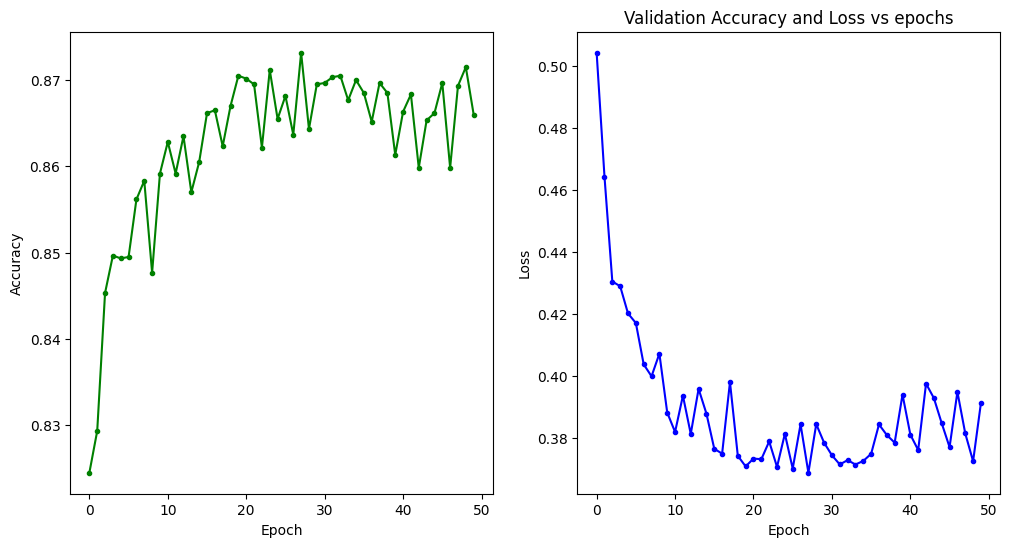

In [ ]:
plot_acc_los(val_accs, val_losses)